# Benchmark: `call_peaks_bdg` (methylation) vs ATAC-seq peaks

Cell type: **STR D2_MSN** (hg38).

`cytozip.call_peaks_bdg` calls peaks from snm3C-seq CpG **hypomethylation**
(`umc = cov - mc`) as an ATAC-like open-chromatin signal. This notebook
benchmarks those peaks against matched **ATAC-seq** peaks (treated as the
open-chromatin ground truth).

**Inputs**
- ATAC peaks: `~/Projects/BG/atac/Subclass.peaks/STR_D2_MSN.macs3.peak.tsv`
- Meth peaks: `~/Projects/BG/pseudobulk/Subclass/D2_MSN_peaks/D2_MSN_peaks.narrowPeak`
- Blacklist: `~/Ref/hg38/annotations/hg38-blacklist.v2.bed.gz`
- GTF: `~/Ref/hg38/annotations/gencode.v43.annotation.gtf`
- Chrom sizes: `~/Ref/hg38/hg38_ucsc.main.chrom.sizes`

**Metrics**: basic peak stats, ENCODE blacklist QC, precision / recall / F1 /
bp-Jaccard against ATAC, precision-recall vs significance cutoff, and TSS /
genomic-annotation distributions. All interval operations are implemented in
numpy (no `bedtools` dependency).

In [13]:
# Paired-Tag H3K27ac peaks (ATAC-INDEPENDENT active-enhancer reference).
H3K27AC = os.path.expanduser('~/Projects/BG/PairedTag/Subclass.H3K27ac.peaks/STR_D2_MSN.macs3.peak.tsv')
# Paired-Tag repressive marks (Polycomb / heterochromatin) for the same subclass.
H3K27ME3 = os.path.expanduser('~/Projects/BG/PairedTag/Subclass.H3K27me3.peaks/STR_D2_MSN.macs3.peak.tsv')
H3K9ME3 = os.path.expanduser('~/Projects/BG/PairedTag/Subclass.H3K9me3.peaks/STR_D2_MSN.macs3.peak.tsv')


## 1. Load peak sets

Both files use narrowPeak column semantics (BED6+4). The ATAC TSV carries a
header row; the meth narrowPeak does not — the loader auto-detects it. `pValue`
is the MACS3/ENCODE convention `-log10(p)` in both. `summit = start + peak`.

In [2]:
NP_COLS = ['chrom', 'start', 'end', 'name', 'score', 'strand',
           'signalValue', 'pValue', 'qValue', 'peak']

def load_narrowpeak(path):
    with open(path) as fh:
        first = fh.readline().split('\t')[0].strip()
    has_header = first.lower() == 'chrom'
    df = pd.read_csv(path, sep='\t', header=0 if has_header else None,
                     names=None if has_header else NP_COLS)
    df.columns = NP_COLS[:df.shape[1]]
    df = df[df['chrom'].isin(MAIN_CHROMS)].copy()
    df['start'] = df['start'].astype(np.int64)
    df['end'] = df['end'].astype(np.int64)
    df['peak'] = pd.to_numeric(df['peak'], errors='coerce')
    df['peak'] = df['peak'].fillna((df['end'] - df['start']) // 2).astype(np.int64)
    df['summit'] = df['start'] + df['peak'].clip(lower=0)
    df['width'] = df['end'] - df['start']
    df['pValue'] = pd.to_numeric(df['pValue'], errors='coerce').fillna(-1.0)
    return df.reset_index(drop=True)

atac = load_narrowpeak(ATAC_PEAKS)
meth = load_narrowpeak(METH_PEAKS)
print('ATAC peaks:', len(atac))
print('Meth (call_peaks_bdg) peaks:', len(meth))
meth.head()

ATAC peaks: 377085
Meth (call_peaks_bdg) peaks: 189633


,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak,summit,width
0,chr1,28716,29652,D2_MSN_peak_1,1000,.,1.15377,205.24357,-1,649,29365,936
1,chr1,48033,48333,D2_MSN_peak_2,1000,.,1.59883,174.41118,-1,298,48331,300
2,chr1,86772,87095,D2_MSN_peak_3,1000,.,1.40213,118.19726,-1,66,86838,323
3,chr1,91042,91731,D2_MSN_peak_4,1000,.,1.46969,3100.00000,-1,168,91210,689
4,chr1,113825,114125,D2_MSN_peak_5,770,.,1.48602,77.08503,-1,125,113950,300


## 2. Interval helpers (numpy)

`overlap_mask` — for each interval in `a`, does it overlap any interval in `b`?
Per chromosome, `b` is sorted by start and a prefix-max of ends lets a single
`searchsorted` decide overlap in `O(n log n)`. `jaccard` computes the
base-pair intersection / union between the two peak sets via a coordinate
sweep on their merged coverages.

In [3]:
def overlap_mask(a, b):
    a = a.reset_index(drop=True)
    mask = np.zeros(len(a), dtype=bool)
    b_groups = {c: (g['start'].to_numpy(), g['end'].to_numpy())
                for c, g in b.groupby('chrom', sort=False)}
    for chrom, ga in a.groupby('chrom', sort=False):
        gb = b_groups.get(chrom)
        if gb is None:
            continue
        bs, be = gb
        o = np.argsort(bs, kind='mergesort')
        bs, be = bs[o], be[o]
        cend = np.maximum.accumulate(be)          # prefix-max of ends
        a_s = ga['start'].to_numpy()
        a_e = ga['end'].to_numpy()
        k = np.searchsorted(bs, a_e, side='left')  # b with start < a_end
        hit = k > 0
        idx = np.clip(k - 1, 0, len(bs) - 1)
        res = np.zeros(len(ga), dtype=bool)
        res[hit] = cend[idx[hit]] > a_s[hit]
        mask[ga.index.to_numpy()] = res
    return mask

def _merge(s, e):
    o = np.argsort(s, kind='mergesort')
    s, e = s[o], e[o]
    cple = np.maximum.accumulate(e)
    new = np.empty(len(s), dtype=bool)
    new[0] = True
    new[1:] = s[1:] > cple[:-1]
    starts = s[new]
    ends = np.maximum.reduceat(e, np.flatnonzero(new))
    return starts, ends

def merged_coverage(df):
    total = 0
    per = {}
    for chrom, g in df.groupby('chrom', sort=False):
        ms, me = _merge(g['start'].to_numpy(), g['end'].to_numpy())
        per[chrom] = (ms, me)
        total += int((me - ms).sum())
    return total, per

def _both_bp(a_s, a_e, b_s, b_e):
    pos = np.concatenate([a_s, a_e, b_s, b_e]).astype(np.int64)
    da = np.concatenate([np.ones(len(a_s)), -np.ones(len(a_e)),
                         np.zeros(len(b_s) + len(b_e))])
    db = np.concatenate([np.zeros(len(a_s) + len(a_e)),
                         np.ones(len(b_s)), -np.ones(len(b_e))])
    o = np.argsort(pos, kind='mergesort')
    pos, da, db = pos[o], da[o], db[o]
    covA = np.cumsum(da)[:-1]
    covB = np.cumsum(db)[:-1]
    seg = np.diff(pos)
    both = (covA > 0) & (covB > 0)
    return int(seg[both].sum())

def jaccard(df_a, df_b):
    a_bp, perA = merged_coverage(df_a)
    b_bp, perB = merged_coverage(df_b)
    inter = 0
    for c in set(perA) & set(perB):
        as_, ae = perA[c]
        bs_, be = perB[c]
        inter += _both_bp(as_, ae, bs_, be)
    union = a_bp + b_bp - inter
    return (inter / union if union else 0.0), inter, a_bp, b_bp

## 3. Basic peak statistics

,set,n_peaks,median_width,mean_width,total_bp_merged,genome_frac_%
0,ATAC,377085,706,860.6,173480167,5.617
1,Meth_bdg,189633,462,631.1,119672642,3.875


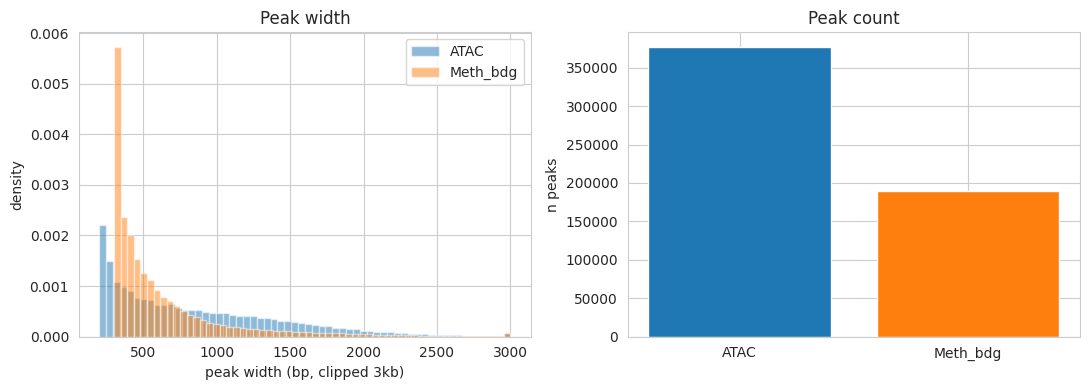

In [4]:
def stats_row(name, df):
    cov, _ = merged_coverage(df)
    return {'set': name, 'n_peaks': len(df),
            'median_width': int(df['width'].median()),
            'mean_width': round(float(df['width'].mean()), 1),
            'total_bp_merged': cov,
            'genome_frac_%': round(100 * cov / GENOME_BP, 3)}

stats = pd.DataFrame([stats_row('ATAC', atac), stats_row('Meth_bdg', meth)])
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, df, c in [('ATAC', atac, 'C0'), ('Meth_bdg', meth, 'C1')]:
    ax[0].hist(np.clip(df['width'], 0, 3000), bins=60, alpha=0.5,
               label=name, color=c, density=True)
ax[0].set(xlabel='peak width (bp, clipped 3kb)', ylabel='density', title='Peak width')
ax[0].legend()
ax[1].bar(stats['set'], stats['n_peaks'], color=['C0', 'C1'])
ax[1].set(ylabel='n peaks', title='Peak count')
plt.tight_layout()
plt.show()

## 4. Blacklist QC

Fraction of peaks overlapping ENCODE hg38 blacklist regions (a low value is a
quality signal). Blacklisted peaks are removed from both sets before the
concordance analysis below.

In [4]:
bl = pd.read_csv(BLACKLIST, sep='\t', header=None, usecols=[0, 1, 2],
                 names=['chrom', 'start', 'end'])
bl = bl[bl['chrom'].isin(MAIN_CHROMS)].reset_index(drop=True)

atac_bl = overlap_mask(atac, bl)
meth_bl = overlap_mask(meth, bl)
print(f'ATAC in blacklist: {atac_bl.sum()} ({100*atac_bl.mean():.2f}%)')
print(f'Meth in blacklist: {meth_bl.sum()} ({100*meth_bl.mean():.2f}%)')

atac_f = atac[~atac_bl].reset_index(drop=True)
meth_f = meth[~meth_bl].reset_index(drop=True)
print('After blacklist removal -> ATAC:', len(atac_f), '| Meth:', len(meth_f))

ATAC in blacklist: 1983 (0.53%)
Meth in blacklist: 16383 (8.64%)
After blacklist removal -> ATAC: 375102 | Meth: 173250


In [6]:
atac_f

,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak,summit,width
0,chr1,819867,820159,.,46,.,1.604047,5.959170,4.602447,105,819972,292
1,chr1,820968,821286,.,24,.,1.446507,3.780430,2.499459,189,821157,318
2,chr1,821834,822097,.,74,.,1.775910,8.845730,7.423444,134,821968,263
3,chr1,826969,827855,.,1000,.,20.530058,2399.912842,2396.194580,570,827539,886
4,chr1,833203,834057,.,981,.,4.454096,100.074089,98.173134,186,833389,854
...,...,...,...,...,...,...,...,...,...,...,...,...
375097,chrY,21602606,21602865,.,76,.,1.790231,9.108900,7.681748,155,21602761,259
375098,chrY,21825092,21825428,.,344,.,2.835727,36.131180,34.460068,156,21825248,336
375099,chrY,26315146,26315354,.,241,.,2.492002,25.715469,24.109518,110,26315256,208
375100,chrY,26348735,26349087,.,942,.,4.368165,96.162613,94.271973,166,26348901,352


In [7]:
meth_f

,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak,summit,width
0,chr1,817040,817340,D2_MSN_peak_29,1000,.,1.26111,139.51132,-1,228,817268,300
1,chr1,826585,828297,D2_MSN_peak_30,1000,.,1.28117,3100.00000,-1,216,826801,1712
2,chr1,833137,833742,D2_MSN_peak_31,1000,.,1.63674,3100.00000,-1,169,833306,605
3,chr1,834357,834663,D2_MSN_peak_32,1000,.,1.42060,3100.00000,-1,96,834453,306
4,chr1,847603,848026,D2_MSN_peak_33,1000,.,1.44239,3100.00000,-1,39,847642,423
...,...,...,...,...,...,...,...,...,...,...,...,...
173245,chrY,20575060,20576645,D2_MSN_peak_189531,1000,.,1.34156,3100.00000,-1,652,20575712,1585
173246,chrY,20742580,20742909,D2_MSN_peak_189532,1000,.,1.76335,165.32810,-1,168,20742748,329
173247,chrY,22235945,22236336,D2_MSN_peak_189533,822,.,1.40207,82.29984,-1,160,22236105,391
173248,chrY,26359905,26360233,D2_MSN_peak_189534,1000,.,1.49085,105.99416,-1,161,26360066,328


## 5. Concordance with ATAC

- **precision** = fraction of meth peaks overlapping an ATAC peak
- **recall** = fraction of ATAC peaks recovered by a meth peak
- **Jaccard** = base-pair intersection / union of the two peak sets

,precision (meth in ATAC),recall (ATAC in meth),F1,Jaccard (bp),intersect_Mb
0,0.7054,0.5501,0.6181,0.3725,77.03


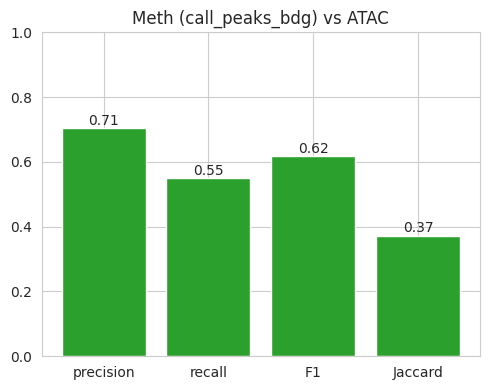

In [6]:
meth_ov = overlap_mask(meth_f, atac_f)
atac_ov = overlap_mask(atac_f, meth_f)

precision = float(meth_ov.mean())
recall = float(atac_ov.mean())
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
jac, inter_bp, a_bp, b_bp = jaccard(atac_f, meth_f)

summary = pd.DataFrame([{
    'precision (meth in ATAC)': round(precision, 4),
    'recall (ATAC in meth)': round(recall, 4),
    'F1': round(f1, 4),
    'Jaccard (bp)': round(jac, 4),
    'intersect_Mb': round(inter_bp / 1e6, 2),
}])
display(summary)

fig, ax = plt.subplots(figsize=(5, 4))
vals = [precision, recall, f1, jac]
ax.bar(['precision', 'recall', 'F1', 'Jaccard'], vals, color='C2')
ax.set(ylim=(0, 1), title='Meth (call_peaks_bdg) vs ATAC')
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

## 5b. Direct top-N peak overlap (Venn)

Compare the top `TOP_N` peaks (ranked by `pValue`) of each assay directly and
draw a Venn diagram. Because a peak can overlap more than one peak in the other
set, the two directional overlap counts differ slightly and are both shown in
the intersection. Change `TOP_N` in the config cell to use a different number.

The **ABC-predicted enhancers** (`EnhancerList.bed`) are added as a third set so
we can see which peak call — ATAC or methylation — overlaps the predicted
enhancers more. The pairwise panels report `ATAC∩enh` and `Meth∩enh` fractions
directly, and the three-way Venn shows them together.


ABC enhancers (blacklist-filtered): 178004
Top 15000 peaks -> ATAC: 15000 | Meth: 15000
ATAC overlapping Meth: 2685 (17.9%)
Meth overlapping ATAC: 2410 (16.1%)
ATAC overlapping enhancers: 15000 (100.0%)
Meth overlapping enhancers: 12658 (84.4%)


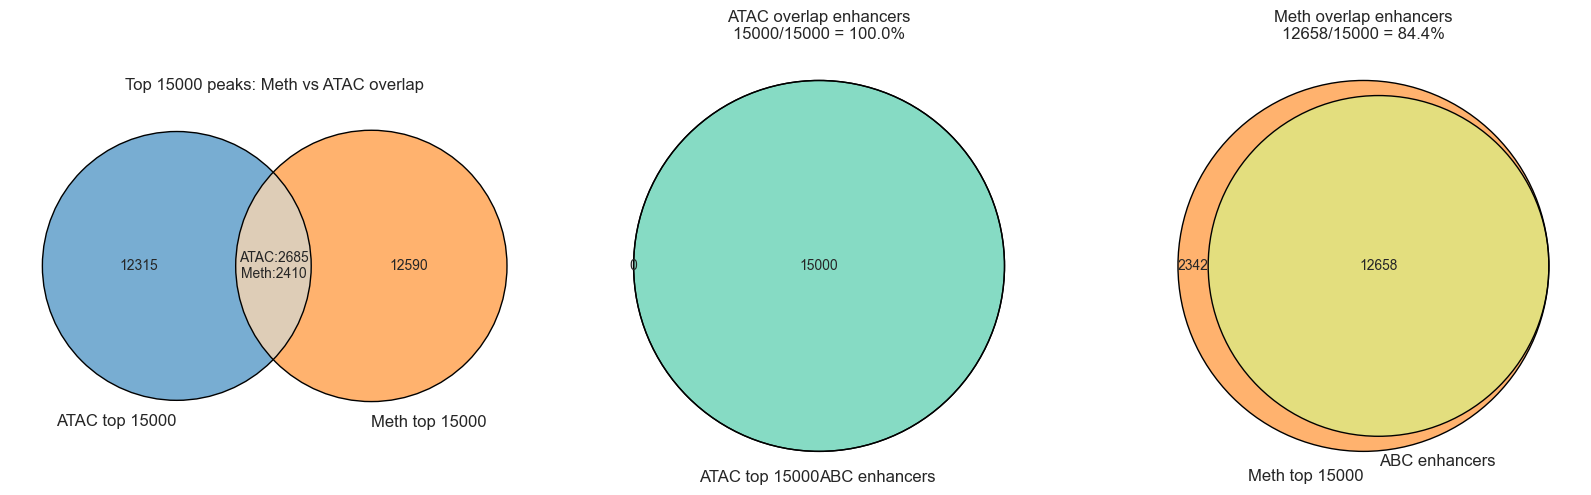

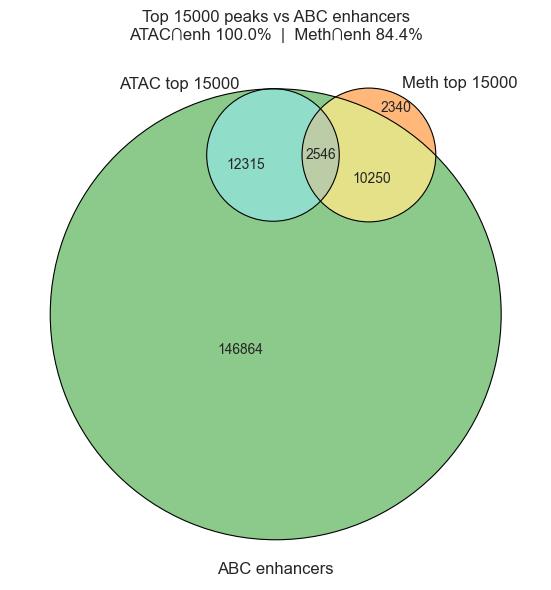

In [5]:
try:
    from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib-venn'])
    from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles


def top_peaks(df, n):
    """Top-n peaks ranked by pValue (-log10 p), descending."""
    return df.sort_values('pValue', ascending=False, kind='mergesort').head(n).reset_index(drop=True)


atac_top = top_peaks(atac_f, TOP_N)
meth_top = top_peaks(meth_f, TOP_N)

# --- ABC-predicted enhancers (third set) ---
enh = pd.read_csv(ENHANCER_BED, sep='\t', header=None, usecols=[0, 1, 2],
                  names=['chrom', 'start', 'end'])
enh = enh[enh['chrom'].isin(MAIN_CHROMS)].copy()
enh['start'] = enh['start'].astype(np.int64)
enh['end'] = enh['end'].astype(np.int64)
enh = enh[~overlap_mask(enh, bl)].reset_index(drop=True)   # drop blacklisted
print(f'ABC enhancers (blacklist-filtered): {len(enh)}')

# Directional overlap counts (a peak may match >1 peak in the other set).
atac_shared = int(overlap_mask(atac_top, meth_top).sum())
meth_shared = int(overlap_mask(meth_top, atac_top).sum())
atac_only = len(atac_top) - atac_shared
meth_only = len(meth_top) - meth_shared
# Single AB area for the circle: mean of the two directional shared counts.
ab = int(round((atac_shared + meth_shared) / 2))

# Enhancer overlap: fraction of each peak set overlapping an ABC enhancer.
atac_e = overlap_mask(atac_top, enh)
meth_e = overlap_mask(meth_top, enh)
atac_enh, meth_enh = int(atac_e.sum()), int(meth_e.sum())

print(f'Top {TOP_N} peaks -> ATAC: {len(atac_top)} | Meth: {len(meth_top)}')
print(f'ATAC overlapping Meth: {atac_shared} ({100*atac_shared/len(atac_top):.1f}%)')
print(f'Meth overlapping ATAC: {meth_shared} ({100*meth_shared/len(meth_top):.1f}%)')
print(f'ATAC overlapping enhancers: {atac_enh} ({100*atac_enh/len(atac_top):.1f}%)')
print(f'Meth overlapping enhancers: {meth_enh} ({100*meth_enh/len(meth_top):.1f}%)')

fig, ax = plt.subplots(1, 3, figsize=(16.5, 5))

# (1) ATAC vs Meth
v = venn2(subsets=(atac_only, meth_only, ab),
          set_labels=(f'ATAC top {TOP_N}', f'Meth top {TOP_N}'),
          set_colors=('C0', 'C1'), alpha=0.6, ax=ax[0])
venn2_circles(subsets=(atac_only, meth_only, ab), linewidth=1, ax=ax[0])
if v.get_label_by_id('11') is not None:
    v.get_label_by_id('11').set_text(f'ATAC:{atac_shared}\nMeth:{meth_shared}')
if v.get_label_by_id('10') is not None:
    v.get_label_by_id('10').set_text(str(atac_only))
if v.get_label_by_id('01') is not None:
    v.get_label_by_id('01').set_text(str(meth_only))
ax[0].set_title(f'Top {TOP_N} peaks: Meth vs ATAC overlap')

# (2) ATAC vs enhancers
va = venn2(subsets=(len(atac_top) - atac_enh, 0, atac_enh),
           set_labels=(f'ATAC top {TOP_N}', 'ABC enhancers'),
           set_colors=('C0', 'C2'), alpha=0.6, ax=ax[1])
venn2_circles(subsets=(len(atac_top) - atac_enh, 0, atac_enh), linewidth=1, ax=ax[1])
if va.get_label_by_id('01') is not None:
    va.get_label_by_id('01').set_text('')
ax[1].set_title(f'ATAC overlap enhancers\n{atac_enh}/{len(atac_top)} = {100*atac_enh/len(atac_top):.1f}%')

# (3) Meth vs enhancers
vm = venn2(subsets=(len(meth_top) - meth_enh, 0, meth_enh),
           set_labels=(f'Meth top {TOP_N}', 'ABC enhancers'),
           set_colors=('C1', 'C2'), alpha=0.6, ax=ax[2])
venn2_circles(subsets=(len(meth_top) - meth_enh, 0, meth_enh), linewidth=1, ax=ax[2])
if vm.get_label_by_id('01') is not None:
    vm.get_label_by_id('01').set_text('')
ax[2].set_title(f'Meth overlap enhancers\n{meth_enh}/{len(meth_top)} = {100*meth_enh/len(meth_top):.1f}%')

plt.tight_layout()
plt.show()

# Three-way Venn (ATAC / Meth / enhancers), peak-membership based.
# Regions are defined from the ATAC and Meth top peaks; enhancer-only counts
# ABC enhancers that overlap neither peak set.
am = overlap_mask(atac_top, meth_top)        # ATAC peak overlaps Meth
ma = overlap_mask(meth_top, atac_top)        # Meth peak overlaps ATAC
enh_a = overlap_mask(enh, atac_top)
enh_b = overlap_mask(enh, meth_top)

Abc = int((~am & ~atac_e).sum())             # ATAC only
aBc = int((~ma & ~meth_e).sum())             # Meth only
abC = int((~enh_a & ~enh_b).sum())           # enhancer only
ABc = int(round(((am & ~atac_e).sum() + (ma & ~meth_e).sum()) / 2))   # ATAC&Meth, not enh
AbC = int((atac_e & ~am).sum())              # ATAC&enh, not Meth
aBC = int((meth_e & ~ma).sum())              # Meth&enh, not ATAC
ABC = int(round(((am & atac_e).sum() + (ma & meth_e).sum()) / 2))     # all three

fig, ax = plt.subplots(figsize=(6.5, 6))
v3 = venn3(subsets=(Abc, aBc, ABc, abC, AbC, aBC, ABC),
           set_labels=(f'ATAC top {TOP_N}', f'Meth top {TOP_N}', 'ABC enhancers'),
           set_colors=('C0', 'C1', 'C2'), alpha=0.55, ax=ax)
venn3_circles(subsets=(Abc, aBc, ABc, abC, AbC, aBC, ABC), linewidth=0.8, ax=ax)
ax.set_title(f'Top {TOP_N} peaks vs ABC enhancers\n'
             f'ATAC∩enh {100*atac_enh/len(atac_top):.1f}%  |  '
             f'Meth∩enh {100*meth_enh/len(meth_top):.1f}%')
plt.tight_layout()
plt.show()


## 5c. Enhancer recall at matched peak count (fairer comparison)

`ATAC∩enhancer ≈ 100%` is largely circular: ABC `EnhancerList.bed` candidate
elements are *derived from* ATAC accessibility peaks, so ATAC trivially covers
them. A fairer question is the **reverse recall**: taking the same number of top
peaks from each assay, what fraction of ABC enhancers does each recover? We
sweep the peak count and also split enhancers by category
(`promoter` / `genic` / `intergenic`), since promoters are recovered easily by
either assay.


{'genic': 83290, 'intergenic': 72301, 'promoter': 22413}


,assay,n_peaks,all,promoter,genic,intergenic
0,ATAC,500,0.0038,0.0236,0.0009,0.0011
1,ATAC,1000,0.0077,0.0474,0.0016,0.0024
2,ATAC,2000,0.0155,0.0953,0.0036,0.0046
3,ATAC,5000,0.0387,0.2295,0.0100,0.0127
4,ATAC,10000,0.0746,0.3833,0.0266,0.0343
5,ATAC,15000,0.1083,0.4522,0.0505,0.0682
6,ATAC,25000,0.1733,0.5160,0.1085,0.1417
7,ATAC,50000,0.3194,0.5840,0.2505,0.3166
8,ATAC,100000,0.5668,0.6453,0.5162,0.6008
9,Meth,500,0.0027,0.0035,0.0032,0.0019


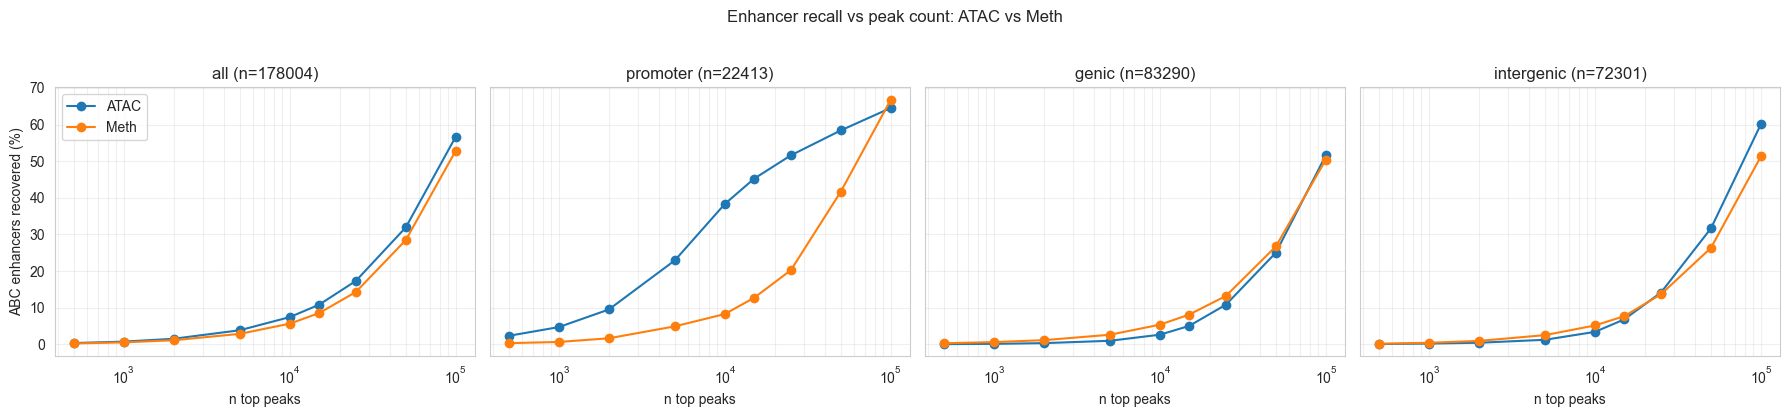


At TOP_N=15000 peaks, ABC enhancer recall:
  all         ATAC  10.8%  |  Meth   8.5%
  promoter    ATAC  45.2%  |  Meth  12.7%
  genic       ATAC   5.0%  |  Meth   8.1%
  intergenic  ATAC   6.8%  |  Meth   7.7%


In [6]:
# Reload enhancers with their ABC category (col 4: "<category>|<coords>").
enh_cat = pd.read_csv(ENHANCER_BED, sep='\t', header=None, usecols=[0, 1, 2, 3],
                      names=['chrom', 'start', 'end', 'name'])
enh_cat = enh_cat[enh_cat['chrom'].isin(MAIN_CHROMS)].copy()
enh_cat['start'] = enh_cat['start'].astype(np.int64)
enh_cat['end'] = enh_cat['end'].astype(np.int64)
enh_cat = enh_cat[~overlap_mask(enh_cat, bl)].reset_index(drop=True)
enh_cat['category'] = enh_cat['name'].str.split('|').str[0]
print(enh_cat['category'].value_counts().to_dict())

# Sweep number of top peaks; recall = fraction of enhancers overlapped by peaks.
n_grid = [500, 1000, 2000, 5000, 10000, 15000, 25000, 50000, 100000]
n_grid = [n for n in n_grid if n <= max(len(atac_f), len(meth_f))]
cats = ['all', 'promoter', 'genic', 'intergenic']
enh_by_cat = {'all': enh_cat}
enh_by_cat.update({c: enh_cat[enh_cat['category'] == c].reset_index(drop=True) for c in cats[1:]})

rows = []
for name, peaks in [('ATAC', atac_f), ('Meth', meth_f)]:
    for n in n_grid:
        if n > len(peaks):
            continue
        sub = top_peaks(peaks, n)
        row = {'assay': name, 'n_peaks': n}
        for c in cats:
            e = enh_by_cat[c]
            row[c] = float(overlap_mask(e, sub).mean()) if len(e) else np.nan
        rows.append(row)
recall = pd.DataFrame(rows)
display(recall.round(4))

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax_i, c in zip(axes, cats):
    for name, col in [('ATAC', 'C0'), ('Meth', 'C1')]:
        d = recall[recall['assay'] == name]
        ax_i.plot(d['n_peaks'], 100 * d[c], 'o-', color=col, label=name)
    ax_i.set(xscale='log', xlabel='n top peaks', title=f'{c} (n={len(enh_by_cat[c])})')
    ax_i.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('ABC enhancers recovered (%)')
axes[0].legend()
fig.suptitle('Enhancer recall vs peak count: ATAC vs Meth', y=1.03)
plt.tight_layout()
plt.show()

# Head-to-head at the notebook's TOP_N.
at = top_peaks(atac_f, min(TOP_N, len(atac_f)))
mt = top_peaks(meth_f, min(TOP_N, len(meth_f)))
print(f'\nAt TOP_N={TOP_N} peaks, ABC enhancer recall:')
for c in cats:
    e = enh_by_cat[c]
    ra = 100 * overlap_mask(e, at).mean()
    rm = 100 * overlap_mask(e, mt).mean()
    print(f'  {c:<11} ATAC {ra:5.1f}%  |  Meth {rm:5.1f}%')


## 5d. Distal enhancers: is methylation ≥ ATAC?

Goal: rigorously test whether **hypomethylation (Meth) peaks identify *distal*
enhancers as well as, or better than, ATAC** — controlling for the two obvious
confounds:

1. **Peak-width / footprint** — Meth peaks could win simply by being wider. So
   every comparison below is made at a **matched genomic footprint (bp)**, not
   just a matched peak count.
2. **Circularity** — ABC candidate elements are *seeded from ATAC*, which gives
   ATAC a built-in advantage. We therefore use ABC's **final gene-linked
   predictions** (`EnhancerPredictions_threshold*.tsv`, thresholded on
   `ABC.Score`), which carry a real enhancer→`TargetGeneTSS` distance, and we
   stratify by that distance. If Meth matches ATAC on **distal** elements
   *despite* ATAC's seeding advantage, the claim is well supported.

Analyses:
- **(A)** Distal-enhancer recall vs matched footprint (Mb).
- **(B)** Fold-enrichment over genome background (footprint-normalized).
- **(C)** Recall stratified by enhancer→TSS distance (the crossover).
- **(D)** Distal-enhancer recovery Venn at matched footprint + `ABC.Score` of the
  elements each assay uniquely recovers.


In [8]:
# --- Load ABC gene-linked predictions and derive per-element distance to TSS ---
pred = pd.read_csv(PRED_ENH, sep='\t',
                   usecols=['chr', 'start', 'end', 'name', 'TargetGeneTSS', 'ABC.Score'])
pred = pred.rename(columns={'chr': 'chrom', 'TargetGeneTSS': 'tss', 'ABC.Score': 'abc'})
pred = pred[pred['chrom'].isin(MAIN_CHROMS)].copy()
pred['start'] = pred['start'].astype(np.int64)
pred['end'] = pred['end'].astype(np.int64)
pred['mid'] = (pred['start'] + pred['end']) // 2
pred['dist'] = (pred['mid'] - pred['tss']).abs()
pred['category'] = pred['name'].str.split('|').str[0]

# One row per element (an element may link to several genes): keep the strongest
# link (max ABC.Score) and its distance.
pred = pred.sort_values('abc', ascending=False, kind='mergesort')
pe = pred.drop_duplicates(subset=['chrom', 'start', 'end'], keep='first').reset_index(drop=True)
pe = pe[~overlap_mask(pe, bl)].reset_index(drop=True)         # drop blacklisted

DISTAL_KB = 10                                                # distal = >10 kb from target TSS
distal = pe[pe['dist'] > DISTAL_KB * 1000].reset_index(drop=True)
proximal = pe[pe['dist'] <= DISTAL_KB * 1000].reset_index(drop=True)
print(f'ABC predicted elements (dedup, blacklist-filtered): {len(pe)}')
print(f'  proximal (<={DISTAL_KB}kb): {len(proximal)} | distal (>{DISTAL_KB}kb): {len(distal)}')

# Peak-width sanity check: Meth must NOT simply be wider.
for name, d in [('ATAC', atac_f), ('Meth', meth_f)]:
    w = (d['end'] - d['start'])
    cov, _ = merged_coverage(d)
    print(f'{name}: n={len(d)} median_width={int(w.median())} '
          f'total_footprint={cov/1e6:.1f} Mb')


def peaks_upto_bp(df, budget_bp):
    """Top peaks by pValue whose cumulative raw width first reaches budget_bp."""
    d = df.sort_values('pValue', ascending=False, kind='mergesort')
    cum = np.cumsum((d['end'] - d['start']).to_numpy())
    k = int(np.searchsorted(cum, budget_bp)) + 1
    return d.iloc[:min(max(k, 1), len(d))].reset_index(drop=True)


def enrichment(peakset, targets):
    """Fold-enrichment: recall / (peak footprint fraction of genome)."""
    frac = overlap_mask(targets, peakset).mean()
    peak_bp, _ = merged_coverage(peakset)
    return frac / (peak_bp / GENOME_BP)


ABC predicted elements (dedup, blacklist-filtered): 27672
  proximal (<=10kb): 14601 | distal (>10kb): 13071
ATAC: n=375102 median_width=707 total_footprint=172.7 Mb
Meth: n=173250 median_width=465 total_footprint=111.2 Mb


Full merged footprint -> ATAC 172.7 Mb | Meth 111.2 Mb
Matched footprint for head-to-head panels: 111 Mb
At 111 Mb -> ATAC 142005 peaks (111.0 Mb) | Meth 172756 peaks (111.0 Mb)


,bin,n,ATAC,Meth
0,0-2k,4695,0.880,0.804
1,2-10k,9906,0.870,0.692
2,10-50k,9869,0.978,0.917
3,50-200k,2819,0.995,0.947
4,>200k,383,0.995,0.924


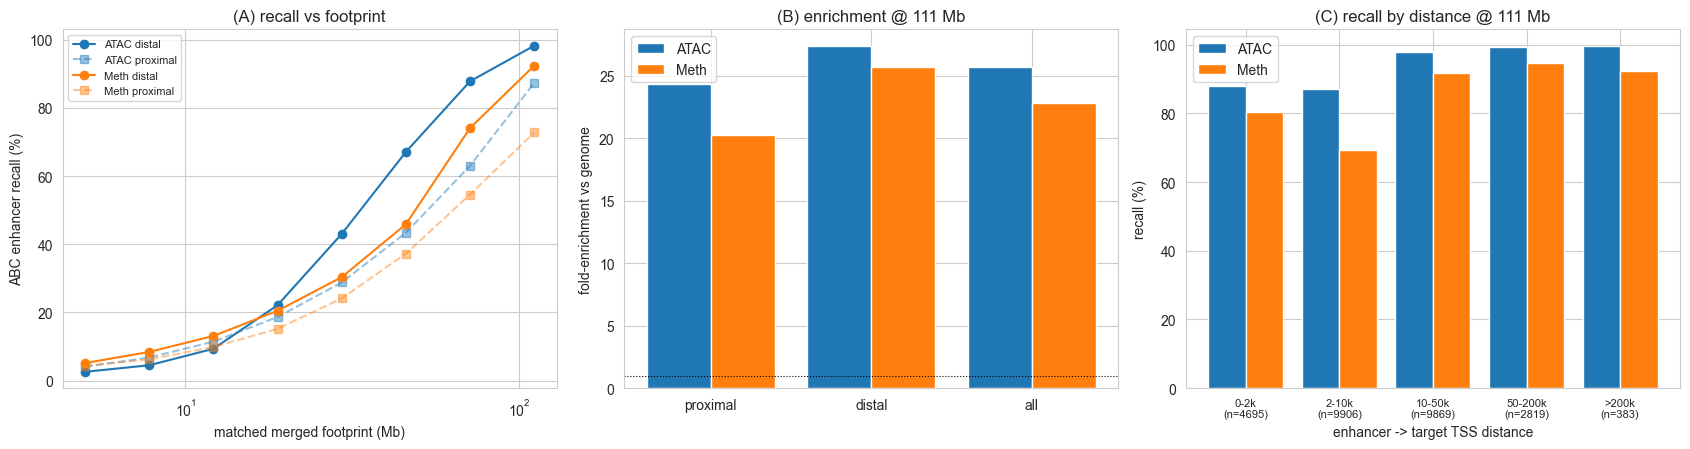

In [10]:
def top_by_merged(df, target_bp):
    """Top peaks (by pValue) whose *merged* genomic footprint first reaches target_bp."""
    d = df.sort_values('pValue', ascending=False, kind='mergesort').reset_index(drop=True)
    full, _ = merged_coverage(d)
    if target_bp >= full:
        return d
    lo, hi = 1, len(d)
    while lo < hi:                      # merged coverage is monotonic in k
        mid = (lo + hi) // 2
        cov, _ = merged_coverage(d.iloc[:mid])
        if cov < target_bp:
            lo = mid + 1
        else:
            hi = mid
    return d.iloc[:lo].reset_index(drop=True)


# Matched genomic footprint = the smaller of the two full merged footprints.
atac_cov, _ = merged_coverage(atac_f)
meth_cov, _ = merged_coverage(meth_f)
MATCH_MB = int(min(atac_cov, meth_cov) / 1e6)
budget_grid_mb = np.geomspace(5, MATCH_MB, 8)
print(f'Full merged footprint -> ATAC {atac_cov/1e6:.1f} Mb | Meth {meth_cov/1e6:.1f} Mb')
print(f'Matched footprint for head-to-head panels: {MATCH_MB} Mb')

# ---- (A) distal recall vs matched *merged* footprint ----
curve = []
for mb in budget_grid_mb:
    for name, peaks in [('ATAC', atac_f), ('Meth', meth_f)]:
        sub = top_by_merged(peaks, mb * 1e6)
        curve.append({'assay': name, 'mb': mb,
                      'distal': float(overlap_mask(distal, sub).mean()),
                      'proximal': float(overlap_mask(proximal, sub).mean())})
curve = pd.DataFrame(curve)

# ---- matched-budget peak subsets (also reused by the Venn cell) ----
atac_m = top_by_merged(atac_f, MATCH_MB * 1e6)
meth_m = top_by_merged(meth_f, MATCH_MB * 1e6)
am_bp, _ = merged_coverage(atac_m)
mm_bp, _ = merged_coverage(meth_m)
print(f'At {MATCH_MB} Mb -> ATAC {len(atac_m)} peaks ({am_bp/1e6:.1f} Mb) | '
      f'Meth {len(meth_m)} peaks ({mm_bp/1e6:.1f} Mb)')

# ---- (B) fold-enrichment over genome background at matched footprint ----
enr = []
for label, tgt in [('proximal', proximal), ('distal', distal), ('all', pe)]:
    enr.append({'set': label,
                'ATAC': enrichment(atac_m, tgt),
                'Meth': enrichment(meth_m, tgt)})
enr = pd.DataFrame(enr).set_index('set')

# ---- (C) recall stratified by enhancer->TSS distance ----
edges = [0, 2000, 10000, 50000, 200000, np.inf]
labels = ['0-2k', '2-10k', '10-50k', '50-200k', '>200k']
pe_bin = pe.assign(bin=pd.cut(pe['dist'], bins=edges, labels=labels, right=False))
strat = []
for lb in labels:
    sub_e = pe_bin[pe_bin['bin'] == lb]
    strat.append({'bin': lb, 'n': len(sub_e),
                  'ATAC': float(overlap_mask(sub_e, atac_m).mean()),
                  'Meth': float(overlap_mask(sub_e, meth_m).mean())})
strat = pd.DataFrame(strat)
display(strat.round(3))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

for name, c in [('ATAC', 'C0'), ('Meth', 'C1')]:
    d = curve[curve['assay'] == name]
    ax[0].plot(d['mb'], 100 * d['distal'], 'o-', color=c, label=f'{name} distal')
    ax[0].plot(d['mb'], 100 * d['proximal'], 's--', color=c, alpha=0.45,
               label=f'{name} proximal')
ax[0].set(xscale='log', xlabel='matched merged footprint (Mb)',
          ylabel='ABC enhancer recall (%)', title='(A) recall vs footprint')
ax[0].legend(fontsize=8)

x = np.arange(len(enr))
ax[1].bar(x - 0.2, enr['ATAC'], 0.4, color='C0', label='ATAC')
ax[1].bar(x + 0.2, enr['Meth'], 0.4, color='C1', label='Meth')
ax[1].axhline(1, color='k', lw=0.8, ls=':')
ax[1].set_xticks(x); ax[1].set_xticklabels(enr.index)
ax[1].set(ylabel='fold-enrichment vs genome',
          title=f'(B) enrichment @ {MATCH_MB} Mb')
ax[1].legend()

xb = np.arange(len(strat))
ax[2].bar(xb - 0.2, 100 * strat['ATAC'], 0.4, color='C0', label='ATAC')
ax[2].bar(xb + 0.2, 100 * strat['Meth'], 0.4, color='C1', label='Meth')
ax[2].set_xticks(xb)
ax[2].set_xticklabels([f'{b}\n(n={n})' for b, n in zip(strat['bin'], strat['n'])], fontsize=8)
ax[2].set(xlabel='enhancer -> target TSS distance',
          ylabel='recall (%)', title=f'(C) recall by distance @ {MATCH_MB} Mb')
ax[2].legend()

plt.tight_layout()
plt.show()


## 5e. ATAC-independent test: H3K27ac enhancers

The ABC panels above are contaminated by **circularity** (ABC elements are
seeded from ATAC), so they cannot fairly decide ATAC vs Meth. Here we use
**Paired-Tag H3K27ac** peaks (`Subclass.H3K27ac.peaks/STR_D2_MSN`) — an
**independent assay** that marks active enhancers/promoters and does *not* use
ATAC — as the enhancer ground truth.

Test: at a **matched genomic footprint**, which peak call recovers more
H3K27ac enhancers, stratified by distance to the nearest TSS? If Meth ≥ ATAC on
**distal** H3K27ac elements here, the claim holds on ATAC-independent evidence.


H3K27ac peaks (blacklist-filtered): 406216
  proximal (<=10kb): 159265 | distal (>10kb): 246951


,bin,n,ATAC,Meth
0,0-2k,75659,0.780,0.784
1,2-10k,83597,0.515,0.485
2,10-50k,167468,0.494,0.471
3,50-200k,73790,0.507,0.463
4,>200k,5702,0.508,0.452


Distal H3K27ac (246951): both=95435 ATAC-only=27511 Meth-only=20247 neither=103758
  recovered by ATAC=49.8%  by Meth=46.8%


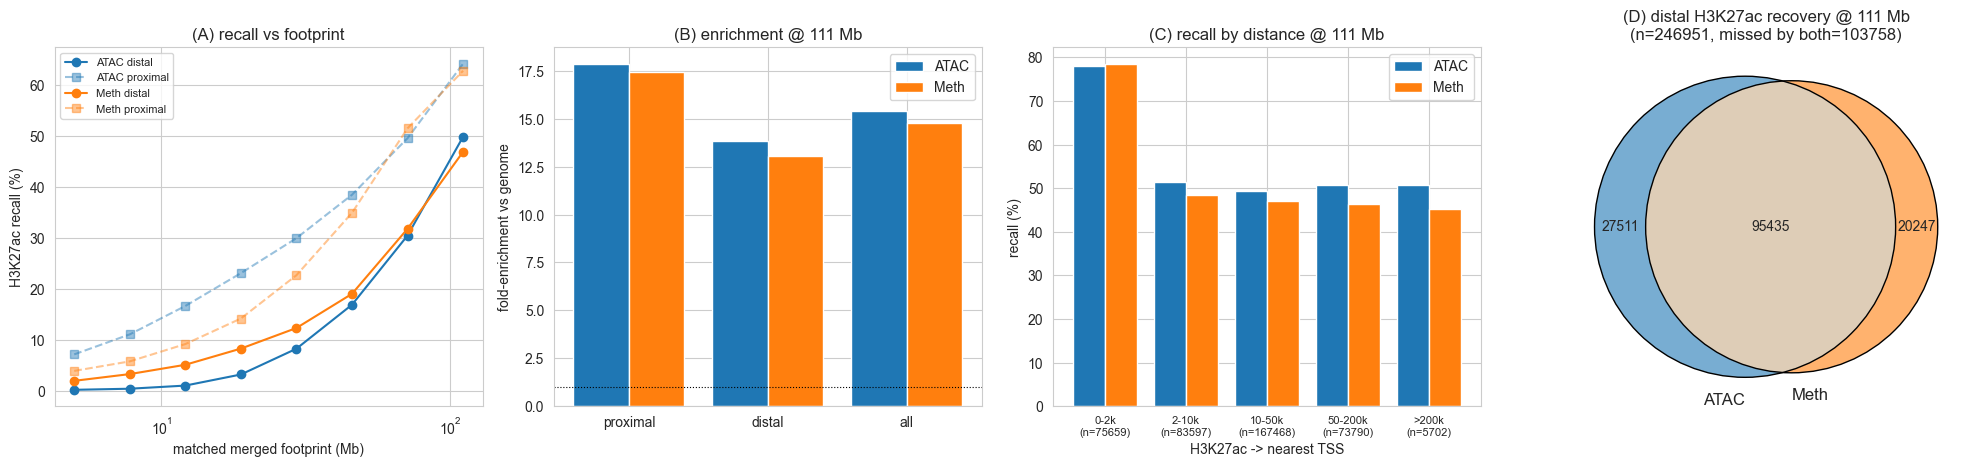

In [12]:
# --- Load ATAC-independent H3K27ac enhancers and classify by TSS distance ---
h3 = load_narrowpeak(H3K27AC)
h3 = h3[~overlap_mask(h3, bl)].reset_index(drop=True)

# Build TSS table from GENCODE if section 7 hasn't run yet.
if 'tss_by' not in globals():
    _gtf = pd.read_csv(GTF, sep='\t', comment='#', header=None, usecols=[0, 2, 3, 4, 6],
                       names=['chrom', 'feature', 'start', 'end', 'strand'])
    _g = _gtf[(_gtf['feature'] == 'gene') & (_gtf['chrom'].isin(MAIN_CHROMS))].copy()
    _tss = np.where(_g['strand'] == '+', _g['start'].astype(np.int64) - 1, _g['end'].astype(np.int64))
    tss_by = {c: np.sort(v) for c, v in pd.Series(_tss, index=_g['chrom']).groupby(level=0)}


def dist_to_tss(df):
    d = np.full(len(df), np.iinfo(np.int64).max, dtype=np.int64)
    for chrom, g in df.groupby('chrom', sort=False):
        t = tss_by.get(chrom)
        if t is None or len(t) == 0:
            continue
        x = g['summit'].to_numpy()
        i = np.searchsorted(t, x)
        il = np.clip(i - 1, 0, len(t) - 1)
        ir = np.clip(i, 0, len(t) - 1)
        d[g.index.to_numpy()] = np.minimum(np.abs(x - t[il]), np.abs(x - t[ir]))
    return d


h3['dist'] = dist_to_tss(h3)
DKB = 10
h3_distal = h3[h3['dist'] > DKB * 1000].reset_index(drop=True)
h3_prox = h3[h3['dist'] <= DKB * 1000].reset_index(drop=True)
print(f'H3K27ac peaks (blacklist-filtered): {len(h3)}')
print(f'  proximal (<={DKB}kb): {len(h3_prox)} | distal (>{DKB}kb): {len(h3_distal)}')

# Reuse the matched-footprint subsets / helpers from 5d.
if 'atac_m' not in globals():
    atac_m = top_by_merged(atac_f, MATCH_MB * 1e6)
    meth_m = top_by_merged(meth_f, MATCH_MB * 1e6)

# ---- (A) H3K27ac recall vs matched footprint ----
h3_curve = []
for mb in budget_grid_mb:
    for name, peaks in [('ATAC', atac_f), ('Meth', meth_f)]:
        sub = top_by_merged(peaks, mb * 1e6)
        h3_curve.append({'assay': name, 'mb': mb,
                         'distal': float(overlap_mask(h3_distal, sub).mean()),
                         'proximal': float(overlap_mask(h3_prox, sub).mean())})
h3_curve = pd.DataFrame(h3_curve)

# ---- (B) fold-enrichment over genome background ----
h3_enr = pd.DataFrame([
    {'set': lbl, 'ATAC': enrichment(atac_m, t), 'Meth': enrichment(meth_m, t)}
    for lbl, t in [('proximal', h3_prox), ('distal', h3_distal), ('all', h3)]
]).set_index('set')

# ---- (C) recall stratified by H3K27ac -> TSS distance ----
edges = [0, 2000, 10000, 50000, 200000, np.inf]
dlabels = ['0-2k', '2-10k', '10-50k', '50-200k', '>200k']
h3_bin = h3.assign(bin=pd.cut(h3['dist'], bins=edges, labels=dlabels, right=False))
h3_strat = pd.DataFrame([
    {'bin': lb, 'n': int((h3_bin['bin'] == lb).sum()),
     'ATAC': float(overlap_mask(h3_bin[h3_bin['bin'] == lb], atac_m).mean()),
     'Meth': float(overlap_mask(h3_bin[h3_bin['bin'] == lb], meth_m).mean())}
    for lb in dlabels])
display(h3_strat.round(3))

# ---- (D) distal-H3K27ac recovery membership (exact Venn) ----
da = overlap_mask(h3_distal, atac_m)
db = overlap_mask(h3_distal, meth_m)
both = int((da & db).sum())
a_only = int((da & ~db).sum())
b_only = int((~da & db).sum())
none = int((~da & ~db).sum())
print(f'Distal H3K27ac ({len(h3_distal)}): both={both} '
      f'ATAC-only={a_only} Meth-only={b_only} neither={none}')
print(f'  recovered by ATAC={100*da.mean():.1f}%  by Meth={100*db.mean():.1f}%')

fig, ax = plt.subplots(1, 4, figsize=(20, 4.6))

for name, c in [('ATAC', 'C0'), ('Meth', 'C1')]:
    d = h3_curve[h3_curve['assay'] == name]
    ax[0].plot(d['mb'], 100 * d['distal'], 'o-', color=c, label=f'{name} distal')
    ax[0].plot(d['mb'], 100 * d['proximal'], 's--', color=c, alpha=0.45, label=f'{name} proximal')
ax[0].set(xscale='log', xlabel='matched merged footprint (Mb)',
          ylabel='H3K27ac recall (%)', title='(A) recall vs footprint')
ax[0].legend(fontsize=8)

x = np.arange(len(h3_enr))
ax[1].bar(x - 0.2, h3_enr['ATAC'], 0.4, color='C0', label='ATAC')
ax[1].bar(x + 0.2, h3_enr['Meth'], 0.4, color='C1', label='Meth')
ax[1].axhline(1, color='k', lw=0.8, ls=':')
ax[1].set_xticks(x); ax[1].set_xticklabels(h3_enr.index)
ax[1].set(ylabel='fold-enrichment vs genome', title=f'(B) enrichment @ {MATCH_MB} Mb')
ax[1].legend()

xb = np.arange(len(h3_strat))
ax[2].bar(xb - 0.2, 100 * h3_strat['ATAC'], 0.4, color='C0', label='ATAC')
ax[2].bar(xb + 0.2, 100 * h3_strat['Meth'], 0.4, color='C1', label='Meth')
ax[2].set_xticks(xb)
ax[2].set_xticklabels([f'{b}\n(n={n})' for b, n in zip(h3_strat['bin'], h3_strat['n'])], fontsize=8)
ax[2].set(xlabel='H3K27ac -> nearest TSS', ylabel='recall (%)',
          title=f'(C) recall by distance @ {MATCH_MB} Mb')
ax[2].legend()

vd = venn2(subsets=(a_only, b_only, both), set_labels=('ATAC', 'Meth'),
           set_colors=('C0', 'C1'), alpha=0.6, ax=ax[3])
venn2_circles(subsets=(a_only, b_only, both), linewidth=1, ax=ax[3])
ax[3].set_title(f'(D) distal H3K27ac recovery @ {MATCH_MB} Mb\n'
                f'(n={len(h3_distal)}, missed by both={none})')

plt.tight_layout()
plt.show()


## 5f. Are Meth-only distal enhancers linked to repressive marks?

Section 5e found ~20k **distal H3K27ac** elements recovered by Meth but *not*
ATAC (`Meth-only`). A worry: hypomethylation also occurs in **partially
methylated domains / heterochromatin**, so some Meth-only calls could sit in
repressive chromatin rather than at real active enhancers.

We test this with two ATAC-independent **repressive** Paired-Tag marks —
**H3K27me3** (Polycomb) and **H3K9me3** (constitutive heterochromatin) — for the
same subclass. For each distal-H3K27ac recovery group (`Meth-only`, `ATAC-only`,
`both`, `neither`) we compute the fraction overlapping each repressive mark and
the fold-enrichment over the genome-wide baseline. If `Meth-only` is *not* more
repressive-associated than `both` / `ATAC-only`, the extra calls are bona-fide
active enhancers, not heterochromatin artifacts.


H3K27me3: 573925 peaks, 311.8 Mb (10.10% genome)
H3K9me3: 534250 peaks, 273.3 Mb (8.85% genome)

Genome baseline: H3K27me3 10.1% | H3K9me3 8.8%


,n,H3K27me3,H3K9me3,either
group,,,,
Meth-only,20247,0.090,0.073,0.117
ATAC-only,27511,0.110,0.099,0.158
both,95435,0.117,0.115,0.168
neither,103758,0.083,0.072,0.121
all distal,246951,0.100,0.092,0.143


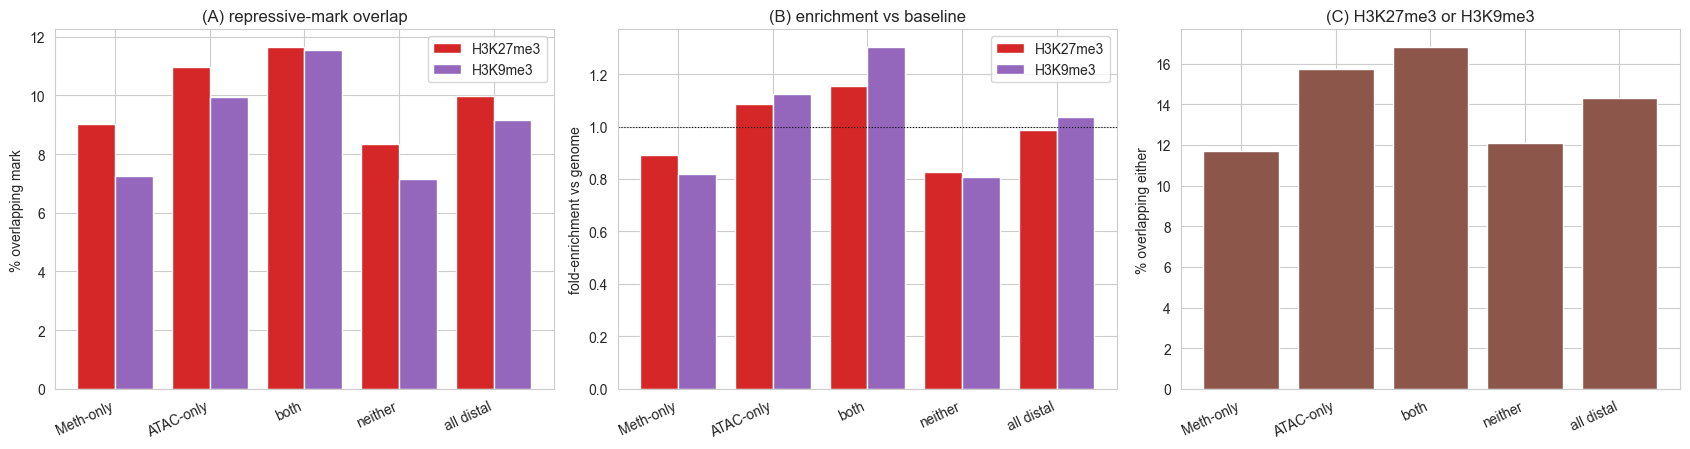

In [16]:
# --- Load ATAC-independent repressive marks (broadPeak-style, no summit col) ---
def load_bed3(path):
    with open(path) as fh:
        has_header = fh.readline().split('\t')[0].strip().lower() == 'chrom'
    r = pd.read_csv(path, sep='\t', header=0 if has_header else None,
                    usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
    r = r[r['chrom'].isin(MAIN_CHROMS)].copy()
    r['start'] = r['start'].astype(np.int64)
    r['end'] = r['end'].astype(np.int64)
    return r.reset_index(drop=True)

rep = {}
for lbl, path in [('H3K27me3', H3K27ME3), ('H3K9me3', H3K9ME3)]:
    r = load_bed3(path)
    r = r[~overlap_mask(r, bl)].reset_index(drop=True)
    cov, _ = merged_coverage(r)
    rep[lbl] = r
    print(f'{lbl}: {len(r)} peaks, {cov/1e6:.1f} Mb ({100*cov/GENOME_BP:.2f}% genome)')

# Distal-H3K27ac recovery categories from 5e (recompute masks if needed).
if 'da' not in globals() or len(da) != len(h3_distal):
    da = overlap_mask(h3_distal, atac_m)
    db = overlap_mask(h3_distal, meth_m)
groups = {
    'Meth-only': h3_distal[~da & db].reset_index(drop=True),
    'ATAC-only': h3_distal[da & ~db].reset_index(drop=True),
    'both': h3_distal[da & db].reset_index(drop=True),
    'neither': h3_distal[~da & ~db].reset_index(drop=True),
    'all distal': h3_distal,
}

base = {m: merged_coverage(r)[0] / GENOME_BP for m, r in rep.items()}  # genome baseline
rows = []
for gname, gdf in groups.items():
    e1 = overlap_mask(gdf, rep['H3K27me3']) if len(gdf) else np.array([], bool)
    e2 = overlap_mask(gdf, rep['H3K9me3']) if len(gdf) else np.array([], bool)
    rows.append({'group': gname, 'n': len(gdf),
                 'H3K27me3': float(e1.mean()) if len(gdf) else np.nan,
                 'H3K9me3': float(e2.mean()) if len(gdf) else np.nan,
                 'either': float((e1 | e2).mean()) if len(gdf) else np.nan})
assoc = pd.DataFrame(rows).set_index('group')
print(f"\nGenome baseline: H3K27me3 {100*base['H3K27me3']:.1f}% | H3K9me3 {100*base['H3K9me3']:.1f}%")
display(assoc.round(3))

order = ['Meth-only', 'ATAC-only', 'both', 'neither', 'all distal']
x = np.arange(len(order))
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

for i, (m, c) in enumerate([('H3K27me3', 'C3'), ('H3K9me3', 'C4')]):
    ax[0].bar(x + (i - 0.5) * 0.4, [100 * assoc.loc[g, m] for g in order], 0.4, label=m, color=c)
ax[0].set_xticks(x); ax[0].set_xticklabels(order, rotation=25, ha='right')
ax[0].set(ylabel='% overlapping mark', title='(A) repressive-mark overlap')
ax[0].legend()

for i, (m, c) in enumerate([('H3K27me3', 'C3'), ('H3K9me3', 'C4')]):
    ax[1].bar(x + (i - 0.5) * 0.4, [assoc.loc[g, m] / base[m] for g in order], 0.4, label=m, color=c)
ax[1].axhline(1, color='k', lw=0.8, ls=':')
ax[1].set_xticks(x); ax[1].set_xticklabels(order, rotation=25, ha='right')
ax[1].set(ylabel='fold-enrichment vs genome', title='(B) enrichment vs baseline')
ax[1].legend()

ax[2].bar(x, [100 * assoc.loc[g, 'either'] for g in order], color='C5')
ax[2].set_xticks(x); ax[2].set_xticklabels(order, rotation=25, ha='right')
ax[2].set(ylabel='% overlapping either', title='(C) H3K27me3 or H3K9me3')

plt.tight_layout()
plt.show()


## 6. Precision / recall vs significance cutoff

Meth peaks are thresholded on `pValue` (`-log10 p`). A higher cutoff keeps
fewer, more confident peaks: precision should rise and recall fall. This shows
whether the peak **ranking** is informative.

,pValue_cutoff,n_meth,precision,recall
0,0,173250,0.7054,0.5501
1,2,173250,0.7054,0.5501
2,5,173250,0.7054,0.5501
3,10,173250,0.7054,0.5501
4,20,173250,0.7054,0.5501
5,50,173250,0.7054,0.5501
6,100,162122,0.7306,0.5370
7,200,115992,0.8338,0.4570
8,500,80375,0.9038,0.3588


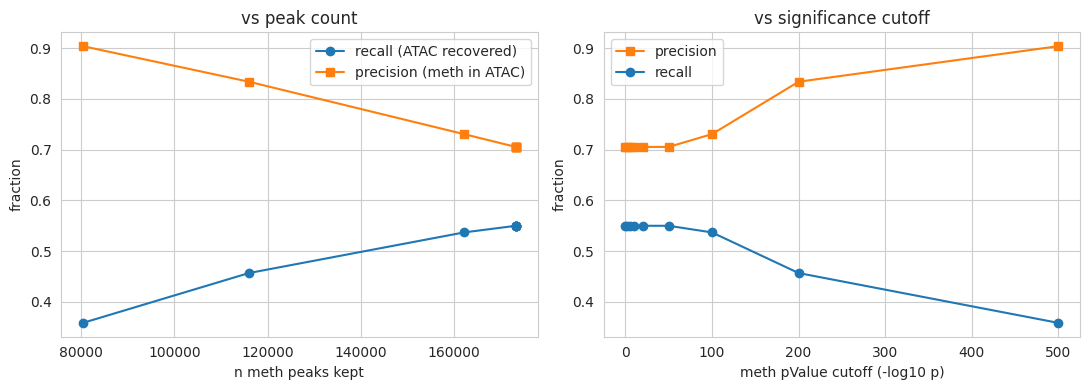

In [7]:
cutoffs = [0, 2, 5, 10, 20, 50, 100, 200, 500]
rows = []
for t in cutoffs:
    sub = meth_f[meth_f['pValue'] >= t]
    if len(sub) == 0:
        continue
    rows.append({'pValue_cutoff': t, 'n_meth': len(sub),
                 'precision': float(overlap_mask(sub, atac_f).mean()),
                 'recall': float(overlap_mask(atac_f, sub).mean())})
sat = pd.DataFrame(rows)
display(sat.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sat['n_meth'], sat['recall'], 'o-', label='recall (ATAC recovered)')
ax[0].plot(sat['n_meth'], sat['precision'], 's-', label='precision (meth in ATAC)')
ax[0].set(xlabel='n meth peaks kept', ylabel='fraction', title='vs peak count')
ax[0].legend()
ax[1].plot(sat['pValue_cutoff'], sat['precision'], 's-', color='C1', label='precision')
ax[1].plot(sat['pValue_cutoff'], sat['recall'], 'o-', color='C0', label='recall')
ax[1].set(xlabel='meth pValue cutoff (-log10 p)', ylabel='fraction', title='vs significance cutoff')
ax[1].legend()
plt.tight_layout()
plt.show()

## 7. TSS distance & genomic annotation

TSS are taken from GENCODE v43 gene records (strand-aware). We compare how
close each peak's summit sits to the nearest TSS and how peaks partition into
promoter (`<=2kb` of a TSS) / gene body / intergenic.

genes: 62703
ATAC: <=1kb of TSS 11.8% | <=5kb 24.4%
Meth_bdg: <=1kb of TSS 10.0% | <=5kb 22.0%


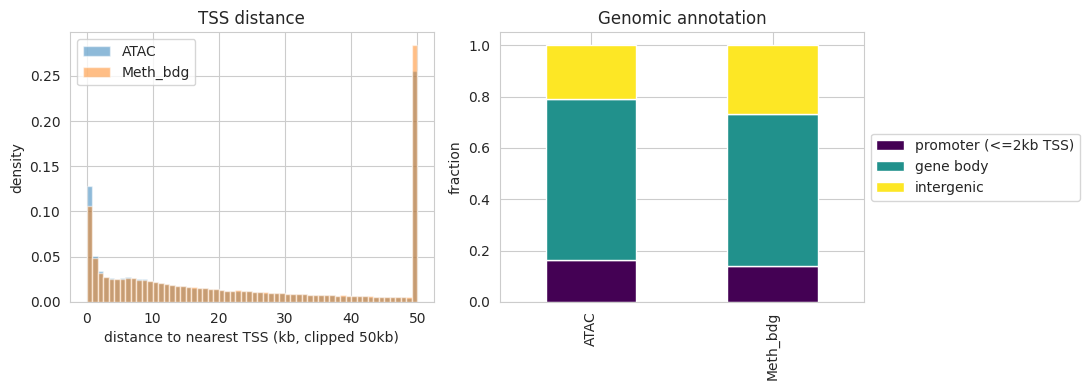

,ATAC,Meth_bdg
promoter (<=2kb TSS),0.161,0.140
gene body,0.630,0.594
intergenic,0.209,0.267


In [8]:
gtf = pd.read_csv(GTF, sep='\t', comment='#', header=None,
                  usecols=[0, 2, 3, 4, 6],
                  names=['chrom', 'feature', 'start', 'end', 'strand'])
genes = gtf[(gtf['feature'] == 'gene') & (gtf['chrom'].isin(MAIN_CHROMS))].copy()
genes['start'] = genes['start'].astype(np.int64) - 1   # GTF 1-based -> 0-based
genes['end'] = genes['end'].astype(np.int64)
genes['tss'] = np.where(genes['strand'] == '+', genes['start'], genes['end'])
tss_by = {c: np.sort(g['tss'].to_numpy())
          for c, g in genes.groupby('chrom', sort=False)}
genes_iv = genes[['chrom', 'start', 'end']]
print('genes:', len(genes))

def nearest_tss(df):
    df = df.reset_index(drop=True)
    dist = np.full(len(df), np.iinfo(np.int64).max, dtype=np.int64)
    for chrom, g in df.groupby('chrom', sort=False):
        t = tss_by.get(chrom)
        if t is None or len(t) == 0:
            continue
        x = g['summit'].to_numpy()
        i = np.searchsorted(t, x)
        il = np.clip(i - 1, 0, len(t) - 1)
        ir = np.clip(i, 0, len(t) - 1)
        d = np.minimum(np.abs(x - t[il]), np.abs(x - t[ir]))
        dist[g.index.to_numpy()] = d
    return dist

atac_d = nearest_tss(atac_f)
meth_d = nearest_tss(meth_f)
for name, d in [('ATAC', atac_d), ('Meth_bdg', meth_d)]:
    print(f'{name}: <=1kb of TSS {100*np.mean(d<=1000):.1f}% | '
          f'<=5kb {100*np.mean(d<=5000):.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, d, c in [('ATAC', atac_d, 'C0'), ('Meth_bdg', meth_d, 'C1')]:
    ax[0].hist(np.clip(d, 0, 50000) / 1000, bins=60, alpha=0.5,
               label=name, color=c, density=True)
ax[0].set(xlabel='distance to nearest TSS (kb, clipped 50kb)', ylabel='density',
          title='TSS distance')
ax[0].legend()

cats = {}
for name, df, d in [('ATAC', atac_f, atac_d), ('Meth_bdg', meth_f, meth_d)]:
    near = d <= 2000
    ingene = overlap_mask(df, genes_iv)
    cats[name] = [float(near.mean()),
                  float((ingene & ~near).mean()),
                  float((~ingene & ~near).mean())]
catdf = pd.DataFrame(cats, index=['promoter (<=2kb TSS)', 'gene body', 'intergenic'])
catdf.T.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set(ylabel='fraction', title='Genomic annotation')
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
display(catdf.round(3))

## 8. Summary

- **Recall** = fraction of ATAC (open-chromatin) peaks the methylation caller
  recovers; **precision** = fraction of methylation peaks that are genuine
  (ATAC-supported). The precision/recall-vs-cutoff curve shows whether the
  `pValue` ranking is usable to trade one for the other.
- **Jaccard** summarises base-pair agreement; peak-count and width differences
  explain much of any precision gap (methylation peaks tend to be broader /
  more numerous).
- **TSS & annotation**: strong TSS enrichment and promoter fraction indicate
  the hypomethylation signal is capturing real regulatory elements. Compare the
  methylation profile against ATAC as the reference shape.

To benchmark another cell type, change `ATAC_PEAKS` / `METH_PEAKS` in the
config cell and re-run.